# Głębokie Uczenie w Praktyce
## Laboratorium 12
### Mateusz Horczak

#### Ćwiczenie 1. Przygotowanie danych

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [15]:
def print_plots(history_dict, tytul_modelu=""):
    epochs = range(1, len(history_dict['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['accuracy'], 'ro', label='Dokładność trenowania')
    plt.plot(epochs, history_dict['val_accuracy'], 'b-', label='Dokładność walidacji')
    plt.title(f'Dokładność trenowania i walidacji ({tytul_modelu})')
    plt.xlabel('Epoki')
    plt.ylabel('Dokładność')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['loss'], 'ro', label='Strata trenowania')
    plt.plot(epochs, history_dict['val_loss'], 'b-', label='Strata walidacji')
    plt.title(f'Strata trenowania i walidacji ({tytul_modelu})')
    plt.xlabel('Epoki')
    plt.ylabel('Strata')
    plt.legend()

    plt.tight_layout()
    plt.show()

#### Ćwiczenie 2. Klasyfikacja recenzji z użyciem warstw Embedding, Bidirectional, LSTM

In [16]:
def prepare_data_imdb(max_tokens=20000, max_length=200):
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_tokens)

    print(f"Ilość sekwencji treningowych: {len(x_train)}")
    print(f"Ilość sekwencji testowych: {len(x_test)}")

    # Wyrównywanie długości recenzji (padding)
    x_train_padded = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_length)
    x_test_padded = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_length)

    print(f"Kształt danych treningowych po paddingu: {x_train_padded.shape}")
    print(f"Kształt danych testowych po paddingu: {x_test_padded.shape}")

    return (x_train_padded, y_train), (x_test_padded, y_test)

In [17]:
(x_train, y_train), (x_test, y_test) = prepare_data_imdb()

Ilość sekwencji treningowych: 25000
Ilość sekwencji testowych: 25000
Kształt danych treningowych po paddingu: (25000, 200)
Kształt danych testowych po paddingu: (25000, 200)


In [18]:
def train_model_lstm(x_train, y_train, x_test, y_test, bidirectional=True):
    max_tokens = 20000
    max_length = 200
    embed_dim = 32

    inputs = keras.Input(shape=(max_length,), dtype="int64")
    embedded = layers.Embedding(input_dim=max_tokens, output_dim=embed_dim, mask_zero=True)(inputs)

    # Wybór między LSTM i Bidirectional LSTM
    if bidirectional:
        x = layers.Bidirectional(layers.LSTM(32))(embedded)
        nazwa = "Bidirectional LSTM"
    else:
        x = layers.LSTM(32)(embedded)
        nazwa = "Standard LSTM"

    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=nazwa.replace(" ", "_"))
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

    print(f"Trenowanie modelu: {nazwa}")
    model.summary()

    callbacks = [
        keras.callbacks.ModelCheckpoint(f"{nazwa.replace(' ', '_')}.keras", save_best_only=True)
    ]

    history = model.fit(x_train, y_train, batch_size=128, validation_data=(x_test, y_test),
                        epochs=10, callbacks=callbacks, verbose=1)

    print_plots(history.history, tytul_modelu=nazwa)

    # Ocena najlepszego modelu
    model_best = keras.models.load_model(f"{nazwa.replace(' ', '_')}.keras")
    test_loss, test_acc = model_best.evaluate(x_test, y_test, verbose=0)
    print(f"Dokładność na zbiorze testowym ({nazwa}): {test_acc:.4f}")

Trenowanie modelu: Standard LSTM


Model: "Standard_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 200, 32)   │    640,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 200)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │      8,320 │ embedding_4[0][0… │
│                     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 648,353 (2.47 MB)

 Trainable params: 648,353 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6989 - loss: 0.5638 - val_accuracy: 0.8418 - val_loss: 0.3707
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8551 - loss: 0.3555 - val_accuracy: 0.8208 - val_loss: 0.4470
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8768 - loss: 0.3100 - val_accuracy: 0.8645 - val_loss: 0.3174
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8960 - loss: 0.2691 - val_accuracy: 0.8630 - val_loss: 0.3963
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9051 - loss: 0.2509 - val_accuracy: 0.8785 - val_loss: 0.3077
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9157 - loss: 0.2244 - val_accuracy: 0.7986 - val_loss: 0.4956
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9307 - loss: 0.1916 - val_accuracy: 0.8554 - val_loss: 0.3434
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9380 - loss: 0.1726 - val_accu

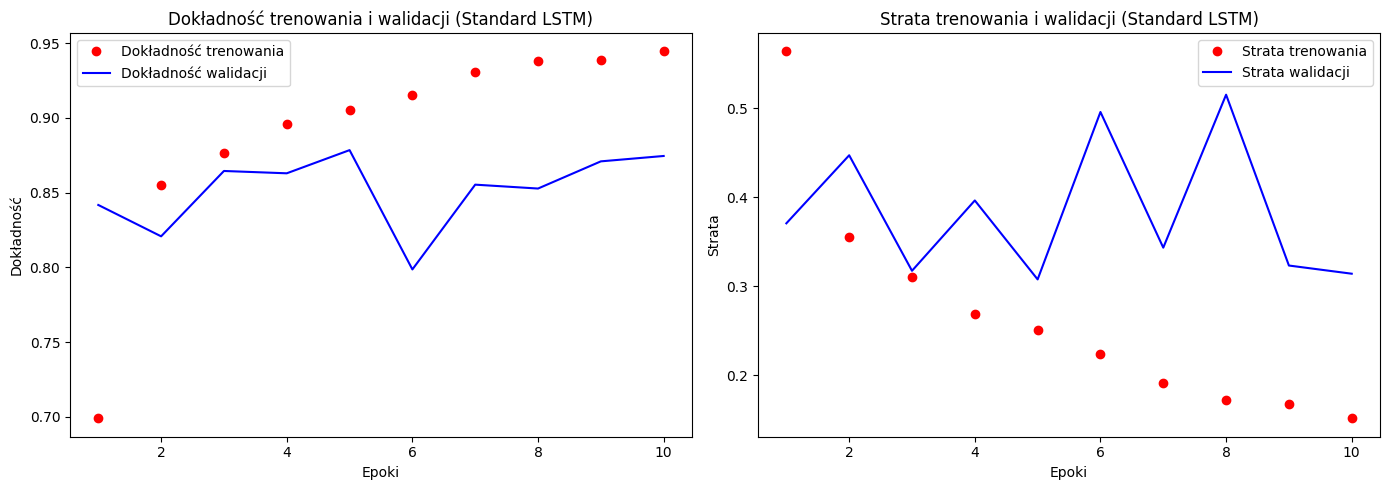

Dokładność na zbiorze testowym (Standard LSTM): 0.8785


In [19]:
train_model_lstm(x_train, y_train, x_test, y_test, bidirectional=False)

Trenowanie modelu: Bidirectional LSTM


Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 200, 32)   │    640,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 200)       │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     16,640 │ embedding_5[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 656,705 (2.51 MB)

 Trainable params: 656,705 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.6890 - loss: 0.5726 - val_accuracy: 0.7641 - val_loss: 0.4772
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8522 - loss: 0.3501 - val_accuracy: 0.8370 - val_loss: 0.3652
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8835 - loss: 0.2918 - val_accuracy: 0.8290 - val_loss: 0.3841
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9056 - loss: 0.2418 - val_accuracy: 0.8500 - val_loss: 0.3946
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9180 - loss: 0.2142 - val_accuracy: 0.8709 - val_loss: 0.3282
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9273 - loss: 0.1946 - val_accuracy: 0.8761 - val_loss: 0.3022
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9326 - loss: 0.1782 - val_accuracy: 0.8605 - val_loss: 0.4316
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9408 - loss: 0.1645 - val_acc

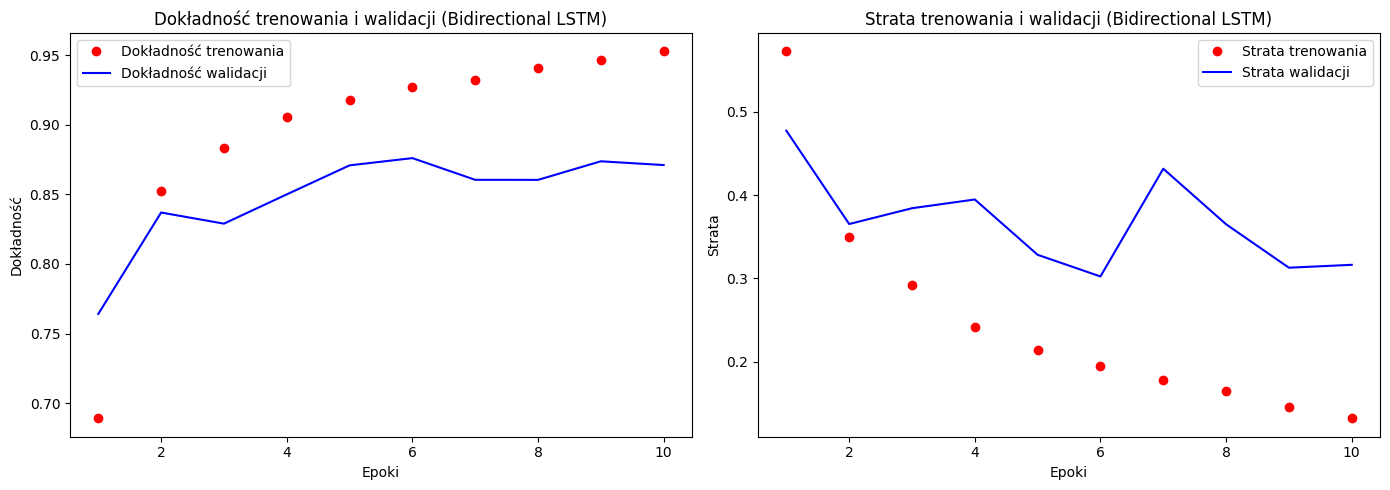

Dokładność na zbiorze testowym (Bidirectional LSTM): 0.8761


In [20]:
train_model_lstm(x_train, y_train, x_test, y_test, bidirectional=True)

#### Ćwiczenie 3. Transformer architektura

In [21]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential([
            layers.Dense(dense_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=input_dim, output_dim=output_dim)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return keras.ops.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

#### Ćwiczenie 4. Transformer Encoder + positional embedding - użyty do klasyfikacji recenzji

In [22]:
def train_model_transformer(x_train, y_train, x_test, y_test):
    vocab_size = 20000
    sequence_length = 200
    embed_dim = 32
    num_heads = 2
    dense_dim = 32

    inputs = keras.Input(shape=(sequence_length,), dtype="int64")
    x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(inputs)
    x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="Transformer_Model")
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

    print("\nRozpoczynam trenowanie modelu: Transformer")
    model.summary()

    callbacks = [
        keras.callbacks.ModelCheckpoint("full_transformer_encoder.keras", save_best_only=True)
    ]

    history = model.fit(x_train, y_train, batch_size=128, validation_data=(x_test, y_test),
                        epochs=10, callbacks=callbacks, verbose=1)

    print_plots(history.history, tytul_modelu="Transformer")

    model_best = keras.models.load_model(
        "full_transformer_encoder.keras",
        custom_objects={
            "TransformerEncoder": TransformerEncoder,
            "PositionalEmbedding": PositionalEmbedding
        }
    )
    test_loss, test_acc = model_best.evaluate(x_test, y_test, verbose=0)
    print(f"Dokładność na zbiorze testowym (Transformer): {test_acc:.4f}")


Rozpoczynam trenowanie modelu: Transformer


/home/mateusz/PycharmProjects/GUwP/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_1' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "Transformer_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 200, 32)   │    646,400 │ input_layer_8[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 200)       │          0 │ input_layer_8[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 200, 32)   │     10,656 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ transformer_enco… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         33 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 657,089 (2.51 MB)

 Trainable params: 657,089 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - accuracy: 0.6602 - loss: 0.6259 - val_accuracy: 0.8239 - val_loss: 0.3966
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.8241 - loss: 0.3951 - val_accuracy: 0.8455 - val_loss: 0.3474
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.8645 - loss: 0.3231 - val_accuracy: 0.8209 - val_loss: 0.3907
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.8836 - loss: 0.2852 - val_accuracy: 0.8404 - val_loss: 0.3548
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.9015 - loss: 0.2470 - val_accuracy: 0.7871 - val_loss: 0.4795
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.9123 - loss: 0.2246 - val_accuracy: 0.8763 - val_loss: 0.2911
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.9203 - loss: 0.2087 - val_accuracy: 0.8602 - val_loss: 0.3507
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.9283 - loss: 0.1892 - 

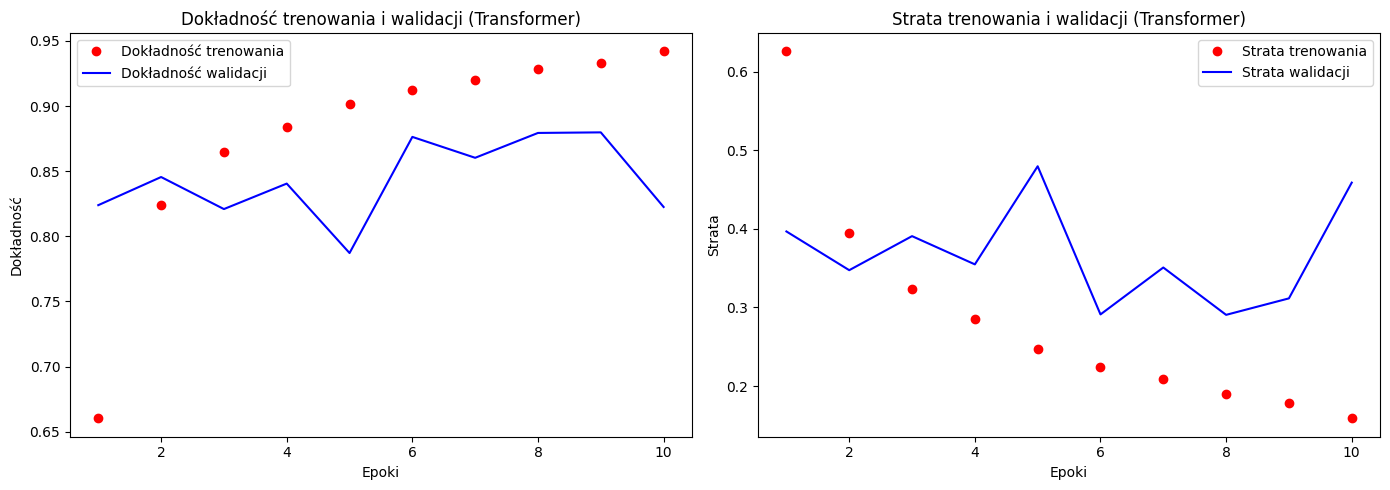

/home/mateusz/PycharmProjects/GUwP/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/mateusz/PycharmProjects/GUwP/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Dokładność na zbiorze testowym (Transformer): 0.8793


In [24]:
train_model_transformer(x_train, y_train, x_test, y_test)